# FN-DSA (Falcon) — 소형 격자 서명
## Falcon: Fast-Fourier Lattice-based Compact Signatures over NTRU

---

이 노트북은 **NIST 표준 전자서명 FN-DSA(Falcon)를 처음 배우는 분**, 특히 수학이 낯선 분을 위한 강의 자료입니다.

전자서명은 "이 문서는 내가 쓴 것이 맞고, 아무도 고치지 않았다"를 증명하는 **디지털 도장**입니다.
Falcon 은 같은 격자 계열 서명인 Dilithium(ML-DSA)과 형제 관계인데, 비유하자면
**같은 내용의 도장을 훨씬 더 작은 잉크로 찍는 기술**입니다. 도장(서명)의 효력은 같은데
찍힌 자국의 크기가 약 1/5 로 줄어듭니다.

이 장에서는 왜 Falcon 의 서명이 작은지를 비유로 이해한 뒤, 직접 만든 축소판 대신
**설계팀이 공개한 파이썬 레퍼런스 구현(`falcon_lib`)을 그대로 실행**하여
키 생성 → 서명 → 검증 → 위조 거부의 전 과정을 실측하고, 서명 크기를 표준 문서 값과 비교합니다.

> **안내**: 이 노트북은 통합본 `양자내성암호_입문자용_v3.ipynb`에서 해당 주제를 분리·정리한 강의 자료입니다.
> 실행 셀과 출력은 원본 그대로이며, 재실행하려면 **0장(Setup)의 공통 설정 셀을 가장 먼저 실행**해야 합니다.

### 학습 목표
1. Falcon 이 Dilithium 과 같은 격자 서명이면서도 **서명(도장 자국)이 훨씬 작은 이유**를
   비유로 설명할 수 있다.
2. "공개키 = 헤매게 만드는 지도, 비밀키 = 지름길 지도"라는 **함정문(trapdoor)** 직관으로
   Falcon 서명의 원리를 이야기할 수 있다.
3. 레퍼런스 구현으로 키 생성 → 서명 → 검증 전 과정을 실행하고, 걸린 시간과 크기를 실측한다.
4. 실측한 Falcon-512 서명 크기를 ML-DSA-65·RSA-3072 와 비교하여 Falcon 의 강점과 한계를 확인한다.
5. "공부용 구현"과 "실서비스용 구현"이 왜 다른지, 실무에서 무엇을 조심해야 하는지 안다.

> **선행 지식**: 어려운 수학은 필요 없습니다. "격자 암호는 점들이 규칙적으로 늘어선 공간에서
> 가장 가까운 점 찾기가 어렵다는 사실을 이용한다"(01장)는 큰 그림과,
> 전자서명이 키 생성(keygen)·서명(sign)·검증(verify) 세 단계로 이루어진다는 것,
> 그리고 "종 모양으로 가운데가 두툼한 확률분포(정규분포)"라는 그림만 떠올릴 수 있으면 충분합니다.

## 0. 준비 (Setup)

실습 전체에서 공통으로 사용하는 도구를 준비합니다. `numpy`, `pandas`, `matplotlib` 를 사용합니다.

아래 셀은 통합본의 공통 설정(Harness) 셀입니다. 실험 결과가 매번 똑같이 나오도록 난수의 출발점을
고정하고(난수 시드 `RNG`), 그래프의 한글이 깨지지 않게 폰트를 자동으로 설정하며,
자주 쓰는 도우미들 — 해시 함수(`H`, `shake`), 데이터 크기를 재는 `nbytes`,
걸린 시간을 재는 `timeit`, 측정값을 모아 두는 저장소 `METRICS` — 를 정의합니다.
노트북을 재실행할 때는 이 셀을 반드시 가장 먼저 실행하세요.

> **주의**: 이 노트북과 같은 폴더에 **`falcon_lib` 폴더**(Falcon 파이썬 레퍼런스 구현)가 있어야 합니다.
> 정리본 폴더에는 이미 함께 복사되어 있습니다.

In [1]:
import time, hashlib, secrets, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import gcd, log2, floor, pi, sqrt

RNG = np.random.default_rng(20260722)   # 재현성 시드
plt.rcParams['figure.dpi'] = 110

# --- 한글 폰트 자동 설정 (그래프의 한글이 □□□로 깨지지 않게) ---
import matplotlib.font_manager as fm

def set_korean_font():
    candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
                  'Noto Sans CJK KR', 'Noto Sans KR', 'NanumBarunGothic']
    installed = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in installed:
            plt.rcParams['font.family'] = name
            plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지
            return name
    # 못 찾으면 리눅스/Colab에서 나눔폰트 설치 시도
    try:
        import subprocess, sys
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'],
                       capture_output=True)
        for path in fm.findSystemFonts():
            if 'Nanum' in path:
                fm.fontManager.addfont(path)
        for name in candidates:
            if name in {f.name for f in fm.fontManager.ttflist}:
                plt.rcParams['font.family'] = name
                plt.rcParams['axes.unicode_minus'] = False
                return name
    except Exception:
        pass
    plt.rcParams['axes.unicode_minus'] = False
    print('⚠️ 한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있어요. '
          'NanumGothic 등 한글 폰트를 설치한 뒤 다시 실행하세요.')
    return None

_font = set_korean_font()

# --- 해시 헬퍼 (해시 기반 서명·KEM 공유비밀에 사용) ---
def H(b: bytes) -> bytes:
    return hashlib.sha256(b).digest()
def shake(b: bytes, n: int) -> bytes:
    return hashlib.shake_128(b).digest(n)

# --- 크기 측정: 객체를 바이트로 직렬화해 대략적 전송량(byte)을 잰다 ---
def nbytes(obj) -> int:
    if isinstance(obj, (bytes, bytearray)):
        return len(obj)
    if isinstance(obj, np.ndarray):
        return obj.astype(np.int64).nbytes
    if isinstance(obj, (list, tuple)):
        return sum(nbytes(x) for x in obj)
    if isinstance(obj, str):
        return len(obj.encode())
    if isinstance(obj, int):
        return (obj.bit_length() + 7) // 8
    return sys.getsizeof(obj)

# --- 시간 측정 ---
def timeit(fn, *a, repeat=1, **k):
    t0 = time.perf_counter()
    for _ in range(repeat):
        out = fn(*a, **k)
    dt = (time.perf_counter() - t0) / repeat
    return out, dt

# --- 정량 지표 저장소 (Part IV 종합 비교에서 사용) ---
METRICS = {}
def log_metric(name, **kv):
    METRICS.setdefault(name, {}).update(kv)

print('Harness 준비 완료 · Python', sys.version.split()[0], '· NumPy', np.__version__,
      '· 한글 폰트:', _font)

Harness 준비 완료 · Python 3.13.14 · NumPy 2.4.6 · 한글 폰트: Malgun Gothic


## 1. Falcon 이론 — 더 작은 격자 서명

### 1-1. 왜 Falcon 도 표준인가

Falcon 은 Dilithium 과 **같은 격자 계열 전자서명**입니다. 둘 다 "격자 도장"인데,
Falcon 은 **같은 내용의 도장을 더 작은 잉크로 찍는 기술** — 즉 도장 자국(서명 데이터)이
훨씬 작게 나오도록 설계된 알고리즘입니다. 서명이 작으면 인터넷으로 보낼 데이터가 줄고
저장 공간도 아낄 수 있어서, NIST 는 상황에 따라 골라 쓸 수 있도록 두 격자 서명을 모두
표준으로 채택했습니다 (Dilithium = ML-DSA, Falcon = FN-DSA).

| 구분 | CRYSTALS-Dilithium (ML-DSA) | **Falcon (FN-DSA)** |
|---|---|---|
| 격자 종류 | Module-LWE | **NTRU 격자** |
| 서명 크기 | 큼 (~3.3 KB @ ML-DSA-65) | **작음 (~0.7 KB @ Falcon-512)** |
| 구현 난이도 | 정수 연산, 비교적 단순 | **부동소수점·가우시안 샘플링, 매우 까다로움** |
| 부채널 | 상대적으로 다루기 쉬움 | 샘플링 누출 주의 필요 |

여기서 **NTRU 격자**(엔트루 격자: 특별한 규칙으로 만든 격자의 한 종류로, 키를 작게 만들 수 있어
오래전부터 쓰여 온 방식)와 **가우시안 샘플링**(종 모양 확률분포를 따라 무작위 숫자를 뽑는 일)이
Falcon 의 두 재료입니다. 지금은 이름만 기억해 두면 됩니다.

### 1-2. NTRU 함정문 — 같은 미로, 두 개의 지도

Falcon 의 심장은 **함정문(trapdoor)** 이라는 아이디어입니다. 비유하면 이렇습니다.

> **함정문 = 같은 미로를 보는 두 개의 지도.**
> 공개 지도(공개키)는 누구나 볼 수 있지만 길이 뒤엉켜 있어서 보면 볼수록 헤매게 만들고,
> 비밀 지도(비밀키)는 같은 미로의 **지름길**을 보여줍니다.
> 서명자는 지름길 지도를 가진 유일한 사람이라서, 메시지가 주어지면
> 그 메시지에 대응하는 "아주 짧은 경로(짧은 벡터)"를 금방 찾아 서명으로 제출할 수 있습니다.
> 검증자는 공개 지도만으로도 "이 경로가 규칙에 맞고 충분히 짧은지"는 확인할 수 있지만,
> 스스로 그런 짧은 경로를 만들어 내지는 못합니다.

검증자가 확인하는 규칙을 굳이 수식으로 쓰면 딱 하나입니다.

$$s_1 + s_2 \cdot h = t$$

> **수식 풀이:** 서명은 두 개의 짧은 숫자 묶음 s₁ 과 s₂ 로 이루어집니다.
> h 는 공개키(공개 지도), t 는 서명할 메시지를 해시로 뭉쳐 만든 "목표 지점"입니다.
> 이 식은 "s₁ 에 s₂ 와 공개키 h 를 곱한 것을 더하면 정확히 목표 지점 t 에 도착해야 한다"는
> 뜻입니다. 아무 s₁, s₂ 로나 t 에 도착하는 것은 쉽지만, **둘 다 아주 짧으면서** 도착하는
> 조합은 비밀 지도 없이는 사실상 찾을 수 없습니다. 검증자는 "도착했는가?"와
> "충분히 짧은가?" 두 가지만 확인합니다.

그러면 서명자는 짧은 s₁, s₂ 를 어떻게 뽑을까요? 여기서 **가우시안 샘플링**이 등장합니다.
아무렇게나 짧은 경로를 고르면 고르는 버릇이 통계적으로 드러나 비밀 지도의 정보가 새어 나갈 수
있습니다. 그래서 Falcon 은 종 모양 확률분포를 따라 "짧은 경로를 자연스럽게 무작위로" 뽑습니다.
이 뽑기를 빠르게 해 주는 기술이 **FFSampling**(fast Fourier sampling: 신호 처리에 쓰이는
고속 푸리에 변환 FFT 를 빌려 와 가우시안 뽑기를 빠르게 수행하는 기법)입니다.

**뽑힌 경로가 짧을수록 서명이 작아집니다.** 즉 "좋은 샘플링이 곧 작은 서명"이고,
Falcon 이 Dilithium 보다 서명이 작은 이유가 바로 이 가우시안 샘플링 기반 함정문 설계에 있습니다.

### 1-3. 왜 축소 구현 대신 레퍼런스 구현인가

이 강의의 다른 장(Kyber·Dilithium 등)은 원리를 드러내기 위해 축소판을 직접 만들어 보았지만,
Falcon 은 그렇게 하지 않습니다. FFSampling 은 소수점 계산의 아주 작은 오차나
연산 시간의 미세한 차이에도 **극도로 민감**해서, 간단하게 흉내 낸 구현은 원리를 왜곡하거나
"이 정도면 안전하겠지"라는 오해를 심어 주기 쉽기 때문입니다.

그래서 이 노트북은 **Falcon 설계팀(Thomas Prest)이 공개한 파이썬 레퍼런스 구현**
(같은 폴더의 `falcon_lib/`)을 그대로 불러와 실행합니다.
키 생성(`ntrugen`) → FFT 샘플링(`ffsampling`) → 서명·검증(`falcon.py`)까지
전 과정이 외부 의존성 없는 순수 파이썬으로 들어 있습니다.

> **주의**: 레퍼런스 구현은 "표준대로 정확히 동작하는가"를 확인하기 위한 **교육·연구용**입니다.
> 연산 시간이 입력에 따라 달라지는 것을 막는 처리(상수시간 보장)가 없으므로,
> 실제 서비스에는 `liboqs` 등 검증된 라이브러리를 사용해야 합니다.

## 2. 레퍼런스 구현 실측 — 키생성·서명·검증·위조 거부

이제 진짜 Falcon 을 돌려 봅니다. 아래 셀은 `falcon_lib` 를 불러와 두 가지 크기 —
연습용 축소판 n=128 과 실제 표준 파라미터 n=512 (Falcon-512) — 로
키 생성(keygen)·서명(sign)에 걸리는 시간과 서명·공개키의 크기를 실측합니다.
(n 은 격자의 크기를 정하는 숫자로, 클수록 안전하지만 느려집니다.)

또한 세 가지 판정을 함께 수행합니다: (1) 정상 서명이 검증을 통과하는가,
(2) 메시지를 살짝 고치면 거부되는가, (3) 서명을 살짝 고치면 거부되는가.
레퍼런스 구현은 거부 이유를 화면에 출력하고 손상된 서명에는 오류를 내기도 하므로,
`quiet_verify` 라는 포장 함수로 조용히 "거부(False)" 판정으로 통일합니다.
마지막으로 n=128 에서 30회 반복하여 정상 통과율과 변조 거부율을 확인합니다.

In [14]:
# ③④ 레퍼런스 구현 실행 — Falcon 키생성·서명·검증·위조거부 (falcon_lib)
import os, io, contextlib
FALCON_DIR = os.path.abspath('falcon_lib')
if not os.path.isdir(FALCON_DIR):
    FALCON_DIR = os.path.abspath('falcon.py-master')   # 폴백
if FALCON_DIR not in sys.path:
    sys.path.insert(0, FALCON_DIR)
from falcon import Falcon as RefFalcon

def quiet_verify(f, vk, m, s):
    """레퍼런스 구현은 거부 사유를 print하고, 손상 서명엔 예외를 던지기도 한다.
    여기서는 '거부(False)'로만 통일해서 조용히 판정한다."""
    try:
        with contextlib.redirect_stdout(io.StringIO()):
            return bool(f.verify(vk, m, s))
    except Exception:
        return False

msg = '양자내성 서명 테스트'.encode()
FALCON512_SIZES = {}

for n in (128, 512):                      # 128 = 빠른 축소판, 512 = 실제 Falcon-512
    f = RefFalcon(n)
    (sk, vk), t_kg = timeit(f.keygen)
    sig, t_sg = timeit(lambda: f.sign(sk, msg))
    ok         = quiet_verify(f, vk, msg, sig)                          # 정상 서명
    forged_msg = quiet_verify(f, vk, msg + b'!', sig)                   # 메시지 변조
    forged_sig = quiet_verify(f, vk, msg, sig[:1] + bytes([sig[1] ^ 1]) + sig[2:])  # 서명 변조
    print(f'n={n:4d} | keygen {t_kg*1000:7.1f} ms | sign {t_sg*1000:6.2f} ms | '
          f'서명 {len(sig):4d} B · 공개키 {len(vk):4d} B | '
          f'정상검증 {ok} | 메시지변조 거부 {not forged_msg} | 서명변조 거부 {not forged_sig}')
    if n == 512:
        FALCON512_SIZES = {'pk': len(vk), 'sig': len(sig)}
        log_metric('FN-DSA (Falcon)', pk_bytes=len(vk), sig_bytes=len(sig),
                   keygen_s=t_kg, sign_s=t_sg)

# 반복 실측: n=128로 30회 — 정상 서명은 전부 통과, 변조는 전부 거부되는지
f128 = RefFalcon(128)
sk, vk = f128.keygen()
ok_cnt = rej_cnt = 0
for i in range(30):
    m = f'메시지 {i}'.encode()
    s = f128.sign(sk, m)
    ok_cnt  += quiet_verify(f128, vk, m, s)
    rej_cnt += (not quiet_verify(f128, vk, m + b'x', s))
print(f'반복 실측(n=128, 30회): 정상 통과 {ok_cnt}/30 · 변조 거부 {rej_cnt}/30')

n= 128 | keygen   157.7 ms | sign   2.49 ms | 서명  200 B · 공개키  224 B | 정상검증 True | 메시지변조 거부 True | 서명변조 거부 True
n= 512 | keygen  2799.5 ms | sign  10.51 ms | 서명  666 B · 공개키  896 B | 정상검증 True | 메시지변조 거부 True | 서명변조 거부 True
반복 실측(n=128, 30회): 정상 통과 30/30 · 변조 거부 30/30


### 2-1. 실측 결과 해석

위 출력에서 확인할 수 있는 사실은 다음과 같습니다.

- **크기**: 실제 파라미터 n=512 에서 **서명 666 B, 공개키 896 B** — 1-1 절 표에서 말한
  "약 0.7 KB" 가 실측으로 확인됩니다. 이메일 한 통에 얹어도 부담 없는 크기입니다.
  축소판 n=128 은 서명 200 B, 공개키 224 B 입니다.
- **시간**: n=512 의 키 생성은 약 2799.5 ms(약 2.8초)로 서명(10.51 ms)보다 훨씬 오래 걸립니다.
  비밀 지도(NTRU 함정문 기저)를 만드는 `ntrugen` 과정이 무겁기 때문인데,
  키는 한 번 만들어 오래 쓰는 물건이라 실용상 큰 문제는 아닙니다.
  도장을 새기는 데는 시간이 걸려도, 한번 새긴 도장을 찍는 일(서명)은 금방인 셈입니다.
  n=128 은 keygen 157.7 ms, sign 2.49 ms 입니다.
- **정확성과 위조 거부**: 두 파라미터 모두 정상 서명은 검증을 통과하고,
  메시지를 한 바이트 바꾸거나 서명을 한 비트 뒤집으면 모두 거부됩니다.
  n=128 반복 실측에서도 **정상 통과 30/30, 변조 거부 30/30** 으로 예외가 없습니다.

> 전자서명이 갖춰야 할 두 성질 — **정당한 서명은 항상 통과, 위조는 항상 거부** — 가
> 레퍼런스 구현에서 그대로 재현되었습니다.

## 3. 시각화 — Falcon 서명은 정말 작은가

방금 실측한 Falcon-512 의 공개키·서명 크기를, 표준 문서에 공표된 ML-DSA-65(Dilithium, FIPS 204)
값, 그리고 참고용으로 지금 널리 쓰이는 고전 서명 RSA-3072 의 값과 나란히 막대그래프로 비교합니다.
"작은 잉크로 찍은 도장"이 실제로 얼마나 작은지 눈으로 확인해 봅시다.

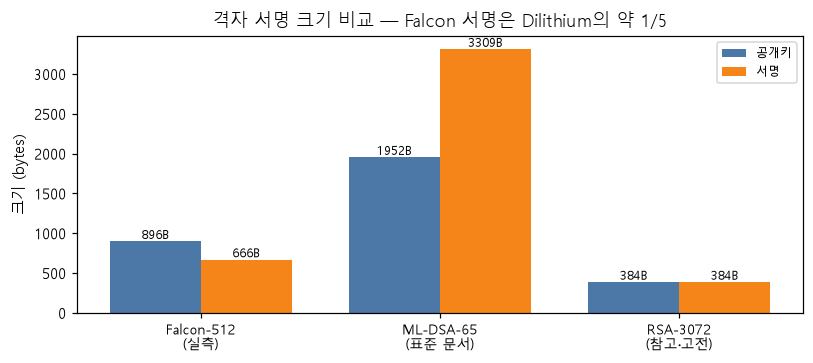

In [15]:
# 실측 Falcon-512 vs 표준 문서 값 비교 (ML-DSA-65: FIPS 204, RSA-3072: 참고용 고전)
names = ['Falcon-512\n(실측)', 'ML-DSA-65\n(표준 문서)', 'RSA-3072\n(참고·고전)']
pk  = [FALCON512_SIZES['pk'], 1952, 384]
sig = [FALCON512_SIZES['sig'], 3309, 384]
x = np.arange(len(names)); w = 0.38
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.bar(x - w/2, pk,  w, label='공개키', color='#4C78A8')
ax.bar(x + w/2, sig, w, label='서명',   color='#F58518')
for xi, v in list(zip(x - w/2, pk)) + list(zip(x + w/2, sig)):
    ax.text(xi, v, f'{v}B', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=9)
ax.set_ylabel('크기 (bytes)')
ax.set_title('격자 서명 크기 비교 — Falcon 서명은 Dilithium의 약 1/5')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### 3-1. 그래프 해석

- **서명 크기**: Falcon-512 는 실측 **666 B**, ML-DSA-65 는 표준 문서 기준 **3309 B** 입니다.
  같은 격자 계열인데도 Falcon 의 서명이 **약 1/5** 에 불과합니다 — 같은 내용의 도장을
  다섯 배 작은 잉크로 찍은 셈입니다. 공개키도 896 B 대 1952 B 로 Falcon 이 절반 이하입니다.
- **RSA-3072 의 함정**: RSA-3072(공개키·서명 각 384 B)가 가장 작아 보이지만,
  RSA 는 **양자컴퓨터(Shor 알고리즘)가 등장하면 깨지는 암호**입니다. 이 비교에서는
  "지금은 작지만 곧 사라질 기준점" 역할일 뿐입니다.

> 같은 격자 서명이라도 설계(Module-LWE 방식 vs NTRU 격자 + 가우시안 샘플링)에 따라
> 서명 크기가 5배 가까이 달라집니다. 이 차이가 두 표준의 쓰임새를 가릅니다.

### 3-2. 실무 적용성

- **측정**: 설계팀 레퍼런스 구현으로 keygen → sign → verify 전 과정이 동작했고,
  메시지 변조·서명 변조가 모두 거부되었습니다. 실측 Falcon-512 서명(666 B, 약 0.7 KB)은
  ML-DSA-65 서명(3309 B)의 **약 1/5** 로, 1-1 절 표의 "~0.7 KB @ Falcon-512" 가
  실측으로 확인되었습니다.
- **적합처**: 서명 데이터가 작아야 하는 환경 — 메모리가 빠듯한 임베디드 기기,
  서명이 여러 겹으로 쌓이는 인증서 체인, 한 바이트가 비용인 블록체인 트랜잭션 — 에서
  Falcon 을 고려합니다. 구현 안정성이 우선이라면 Dilithium(ML-DSA)이 무난합니다.
- **주의**: 이 레퍼런스 구현은 "표준대로 정확히 동작하는가"를 보는 **정확성 기준(reference)** 이지
  보안 구현이 아닙니다. 연산 시간이 입력에 따라 달라지기 때문에, 가우시안 샘플링 과정이
  사이드채널 공격(기기의 전력 소모나 연산 시간을 훔쳐보고 비밀을 알아내는 공격)에
  노출될 수 있습니다. 실서비스에는 `liboqs` 같은 검증된 라이브러리를 사용해야 합니다.

## 연습문제

직접 코드를 고쳐 보면서 감을 잡아 보세요. 정답보다 "바꿔 보고 관찰하는 것" 자체가 목적입니다.

1. **파라미터 스케일링**: 2장 실측 셀의 `for n in (128, 512):` 을 `(64, 128, 256, 512)` 로 바꿔
   실행하고, n 이 2배가 될 때 keygen·sign 시간과 서명·공개키 크기가 각각 몇 배쯤
   커지는지 표로 정리해 보세요. (n 은 2를 거듭 곱한 수만 가능하며, n=1024 는 keygen 이
   수십 초 이상 걸릴 수 있습니다.)

2. **변조 위치 실험**: 서명 변조 실험은 `sig[:1] + bytes([sig[1] ^ 1]) + sig[2:]` 로
   서명의 두 번째 바이트에서 딱 1비트만 뒤집습니다. 뒤집는 위치를 서명의 중간·끝으로 바꾸거나
   첫 바이트(헤더)를 변조해 보고, 어느 위치를 건드리든 `quiet_verify` 가 거부하는지 확인해 보세요.

3. **메시지 길이와 서명 시간**: `msg` 를 수십 KB 길이의 긴 바이트열(예: `b'A' * 50000`)로
   바꿔 sign 시간이 얼마나 달라지는지 재 보세요. 긴 문서를 먼저 해시로 짧게 요약한 뒤
   요약본에 서명하는 구조라면, 문서가 길어져도 서명 시간은 거의 그대로일 것입니다.
   반복 실측의 횟수 30을 100으로 늘려 통과/거부율도 다시 확인해 보세요.

4. **비교 대상 추가**: 3장 시각화 셀의 `names`, `pk`, `sig` 리스트에 해시 기반 서명
   **SLH-DSA(SPHINCS+)** 의 공개키·서명 크기를 표준 문서(FIPS 205)에서 찾아 추가하고,
   "격자 서명은 작고 해시 서명은 크다"는 경향이 그래프에서 어떻게 드러나는지 관찰해 보세요.

## 요약

- Falcon(표준명 **FN-DSA**)은 Dilithium(ML-DSA)과 같은 격자 계열 서명이지만,
  **NTRU 격자 + 가우시안 샘플링(FFSampling)** 설계 덕분에 서명이 훨씬 작습니다 —
  같은 내용의 도장을 더 작은 잉크로 찍는 기술입니다.
- 원리는 격자 **함정문**입니다 — 같은 미로를 보는 두 개의 지도 중,
  공개 지도(공개키)만으로는 찾을 수 없는 짧은 경로(짧은 벡터)를
  비밀 지도(비밀키)를 가진 서명자만 뽑아서 서명으로 제출합니다. 경로가 짧을수록 서명이 작습니다.
- FFSampling 은 소수점 오차와 연산 시간 차이에 극도로 민감하므로, 축소 구현 대신
  **설계팀의 파이썬 레퍼런스 구현(`falcon_lib`)** 을 그대로 실행해 검증했습니다.
- 실측 결과: n=512 에서 **서명 666 B·공개키 896 B**, keygen 약 2.8 초·sign 약 10.5 ms.
  n=128 반복 실측에서 정상 통과 30/30, 변조 거부 30/30 을 확인했습니다.
- Falcon-512 서명은 ML-DSA-65(3309 B)의 **약 1/5** — 임베디드 기기·인증서 체인·블록체인처럼
  바이트가 아까운 환경에 적합합니다. 구현 안정성이 우선이면 Dilithium 을 씁니다.
- 레퍼런스 구현은 상수시간 보장이 없어 교육·연구용입니다. **실서비스에는 `liboqs` 등
  검증된 라이브러리가 필수**입니다.

> Falcon 은 NIST 가 FN-DSA 라는 이름으로 표준화를 진행 중인 서명입니다(FIPS 206 예정).
> "작은 서명"이라는 강점과 "까다로운 구현"이라는 대가를 함께 가진 알고리즘으로,
> ML-DSA 와 서로 부족한 부분을 채워 주는 짝으로 쓰입니다.